In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("Amazon.csv")

print(df.head())
print(df.info())

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_13940\3938730911.py:4: DtypeWarning: Columns (0: Unnamed: 22) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Amazon.csv")


   index             Order ID      Date                        Status  \
0      0  405-8078784-5731545  04-30-22                     Cancelled   
1      1  171-9198151-1101146  04-30-22  Shipped - Delivered to Buyer   
2      2  404-0687676-7273146  04-30-22                       Shipped   
3      3  403-9615377-8133951  04-30-22                     Cancelled   
4      4  407-1069790-7240320  04-30-22                       Shipped   

  Fulfilment Sales Channel  ship-service-level    Style              SKU  \
0   Merchant      Amazon.in           Standard   SET389   SET389-KR-NP-S   
1   Merchant      Amazon.in           Standard  JNE3781  JNE3781-KR-XXXL   
2     Amazon      Amazon.in          Expedited  JNE3371    JNE3371-KR-XL   
3   Merchant      Amazon.in           Standard    J0341       J0341-DR-L   
4     Amazon      Amazon.in          Expedited  JNE3671  JNE3671-TU-XXXL   

        Category  ... currency  Amount    ship-city   ship-state  \
0            Set  ...      INR  647.

In [ ]:
df = df.drop(columns=["index","Order ID","ASIN","SKU","Unnamed: 22"], errors="ignore")
df["Date"] = pd.to_datetime(df["Date"])
df = df.dropna(subset=["Amount","Qty"])

In [5]:
print(df["Amount"].describe())

count    121180.000000
mean        648.561465
std         281.211687
min           0.000000
25%         449.000000
50%         605.000000
75%         788.000000
max        5584.000000
Name: Amount, dtype: float64


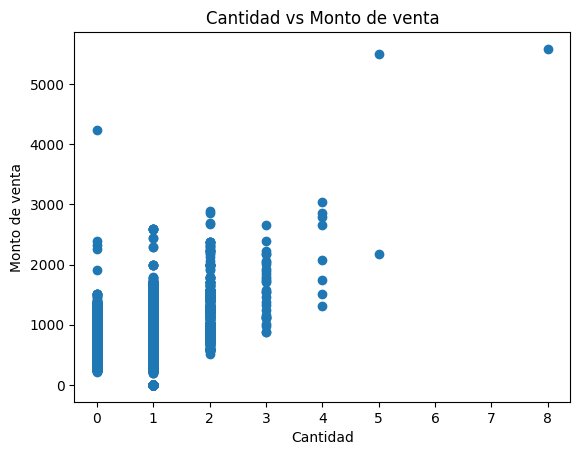

In [10]:
plt.scatter(df["Qty"], df["Amount"])
plt.xlabel("Cantidad")
plt.ylabel("Monto de venta")
plt.title("Cantidad vs Monto de venta")
plt.show()

In [7]:
category_sales = df.groupby("Category")["Amount"].mean().sort_values(ascending=False)

print(category_sales)

Category
Set              833.385571
Saree            799.572645
Western Dress    762.790580
Ethnic Dress     723.895389
Top              526.098603
Blouse           520.327106
kurta            455.927108
Bottom           358.733286
Dupatta          305.000000
Name: Amount, dtype: float64


In [9]:
df.groupby("Sales Channel")["Amount"].mean()

KeyError: 'Sales Channel'